In [3]:
!pip install git+https://github.com/openai/CLIP.git -q

import os
import shutil
import numpy as np
import clip
import torch
from PIL import Image
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
Using device: cuda


In [4]:
from google.colab import drive
import json
import os
import numpy as np

drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/PlantDisease_Project'
CACHE_DIR = f'{BASE_DIR}/cache'
PLANTVILLAGE_RAW   = f'{BASE_DIR}/datasets/PlantVillage/raw/train'
CASSAVA_RAW        = f'{BASE_DIR}/datasets/Cassava/raw/train'
PLANTVILLAGE_SPLIT = f'{BASE_DIR}/datasets/PlantVillage/split'
CASSAVA_SPLIT      = f'{BASE_DIR}/datasets/Cassava/split'
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Auto reload splits ─────────────────────────────────
pv_json  = f'{CACHE_DIR}/pv_splits.json'
cas_json = f'{CACHE_DIR}/cas_splits.json'

if os.path.exists(pv_json):
    with open(pv_json, 'r') as f:
        pv = json.load(f)
    pv_X_train = pv['X_train']
    pv_X_val   = pv['X_val']
    pv_X_test  = pv['X_test']
    pv_y_train = pv['y_train']
    pv_y_val   = pv['y_val']
    pv_y_test  = pv['y_test']
    pv_classes = sorted(list(set(pv_y_train)))  # ← ADD THIS
    print(f" PV splits loaded — Train:{len(pv_X_train)} "
          f"Val:{len(pv_X_val)} Test:{len(pv_X_test)}")
    print(f"   PV classes: {len(pv_classes)}")
else:
    print(" PV splits not found")

if os.path.exists(cas_json):
    with open(cas_json, 'r') as f:
        cas = json.load(f)
    cas_X_train = cas['X_train']
    cas_X_val   = cas['X_val']
    cas_X_test  = cas['X_test']
    cas_y_train = cas['y_train']
    cas_y_val   = cas['y_val']
    cas_y_test  = cas['y_test']
    cas_classes = sorted(list(set(cas_y_train)))  # ← ADD THIS
    print(f" Cassava splits loaded — Train:{len(cas_X_train)} "
          f"Val:{len(cas_X_val)} Test:{len(cas_X_test)}")
    print(f"   Cassava classes: {len(cas_classes)}")
else:
    print(" Cassava splits not found")

print("\n Cell 2 complete!")

Mounted at /content/drive
 PV splits loaded — Train:36554 Val:5223 Test:10445
   PV classes: 36
 Cassava splits loaded — Train:3958 Val:566 Test:1132
   Cassava classes: 5

 Cell 2 complete!


In [ ]:
def collect_images(dataset_path):
    all_images = []
    all_labels = []

    classes = sorted([
        c for c in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, c))
    ])

    print(f"Classes found ({len(classes)}):")
    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        imgs = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        for img in imgs:
            all_images.append(os.path.join(cls_path, img))
            all_labels.append(cls)
        print(f"  {cls}: {len(imgs)} images")

    print(f"\\nTotal: {len(all_images)} images, {len(classes)} classes")
    return all_images, all_labels, classes

In [ ]:
# ── NEW CELL 4 — Split without copying ──────────────────
import json
from sklearn.model_selection import train_test_split

def split_and_save(all_images, all_labels, save_path):
    """
    Split dataset and save paths to JSON.
    No file copying — just saves paths. Takes seconds!
    """
    # 80% trainval, 20% test
    X_tv, X_test, y_tv, y_test = train_test_split(
        all_images, all_labels,
        test_size=0.20,
        stratify=all_labels,
        random_state=42
    )

    # 70% train, 10% val
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv,
        test_size=0.125,
        stratify=y_tv,
        random_state=42
    )

    print(f"Train : {len(X_train)} images")
    print(f"Val   : {len(X_val)} images")
    print(f"Test  : {len(X_test)} images")

    # Save paths to JSON — no copying!
    split_data = {
        'X_train': X_train,
        'X_val'  : X_val,
        'X_test' : X_test,
        'y_train': y_train,
        'y_val'  : y_val,
        'y_test' : y_test
    }

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, 'w') as f:
        json.dump(split_data, f)

    print(f"✅ Split saved to {save_path}")
    return X_train, X_val, X_test, y_train, y_val, y_test

print("✅ Function defined!")

✅ Function defined!


In [ ]:
# ── NEW CELL 5 — Split PlantVillage ─────────────────────
print("=" * 50)
print("SPLITTING PLANTVILLAGE")
print("=" * 50)

pv_images, pv_labels, pv_classes = collect_images(PLANTVILLAGE_RAW)

result = split_and_save(
    pv_images, pv_labels,
    save_path=f'{CACHE_DIR}/pv_splits.json'
)

pv_X_train = result[0]
pv_X_val   = result[1]
pv_X_test  = result[2]
pv_y_train = result[3]
pv_y_val   = result[4]
pv_y_test  = result[5]

print("PlantVillage split done in seconds!")

SPLITTING PLANTVILLAGE
Classes found (38):
  Apple___Apple_scab: 630 images
  Apple___Black_rot: 458 images
  Apple___Cedar_apple_rust: 0 images
  Apple___healthy: 0 images
  Blueberry___healthy: 1502 images
  Cherry_(including_sour)___Powdery_mildew: 1052 images
  Cherry_(including_sour)___healthy: 854 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn_(maize)___Common_rust_: 1192 images
  Corn_(maize)___Northern_Leaf_Blight: 985 images
  Corn_(maize)___healthy: 1162 images
  Grape___Black_rot: 1180 images
  Grape___Esca_(Black_Measles): 1383 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
  Grape___healthy: 423 images
  Orange___Haunglongbing_(Citrus_greening): 5507 images
  Peach___Bacterial_spot: 2297 images
  Peach___healthy: 360 images
  Pepper,_bell___Bacterial_spot: 997 images
  Pepper,_bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Raspberry___hea

In [ ]:
# ── NEW CELL 6 — Split Cassava ───────────────────────────
print("=" * 50)
print("SPLITTING CASSAVA")
print("=" * 50)

cas_images, cas_labels, cas_classes = collect_images(CASSAVA_RAW)

result = split_and_save(
    cas_images, cas_labels,
    save_path=f'{CACHE_DIR}/cas_splits.json'
)

cas_X_train = result[0]
cas_X_val   = result[1]
cas_X_test  = result[2]
cas_y_train = result[3]
cas_y_val   = result[4]
cas_y_test  = result[5]

print("Cassava split done in seconds!")

SPLITTING CASSAVA
Classes found (5):
  cbb: 466 images
  cbsd: 1443 images
  cgm: 773 images
  cmd: 2658 images
  healthy: 316 images
\nTotal: 5656 images, 5 classes
Train : 3958 images
Val   : 566 images
Test  : 1132 images
✅ Split saved to /content/drive/MyDrive/PlantDisease_Project/cache/cas_splits.json
✅ Cassava split done in seconds!


In [ ]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print("CLIP loaded!")

Using device: cuda


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 110MiB/s]


CLIP loaded!


In [ ]:
import time
from PIL import Image

def extract_features(image_paths, model, preprocess, device, batch_size=64):
    all_features = []
    total_batches = (len(image_paths) + batch_size - 1) // batch_size
    start_time = time.time()

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs  = []

        for path in batch_paths:
            try:
                img = preprocess(Image.open(path).convert("RGB"))
                batch_imgs.append(img)
            except:
                batch_imgs.append(torch.zeros(3, 224, 224))

        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.no_grad():
            feats = model.encode_image(batch_tensor)
            feats = feats / feats.norm(dim=-1, keepdim=True)

        all_features.append(feats.cpu().numpy())

        done_imgs    = min(i + batch_size, len(image_paths))
        done_batches = (i // batch_size) + 1
        pct          = done_imgs / len(image_paths)
        elapsed      = time.time() - start_time

        if done_batches > 1:
            time_per_batch = elapsed / done_batches
            remaining      = time_per_batch * (total_batches - done_batches)
            mins_left      = int(remaining // 60)
            secs_left      = int(remaining % 60)
            eta            = f"ETA: {mins_left}m {secs_left}s"
        else:
            eta = "ETA: calculating..."

        bar_len = 30
        filled  = int(bar_len * pct)
        bar     = '█' * filled + '░' * (bar_len - filled)

        print(f"\r  [{bar}] {done_imgs}/{len(image_paths)} "
              f"({pct*100:.1f}%) | {eta}    ", end='')

    print(f"\n  Total time: {int((time.time()-start_time)//60)}m "
          f"{int((time.time()-start_time)%60)}s")
    return np.vstack(all_features)

print("extract_features function defined!")

extract_features function defined!


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Check GPU memory first
if torch.cuda.is_available():
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory: {mem:.1f} GB")

# Load larger DINO2 model
dino2_model = torch.hub.load(
    'facebookresearch/dinov2',
    'dinov2_vitb14'    # ← vitb14 instead of vits14
)
dino2_model = dino2_model.to(device)
dino2_model.eval()

print(" DINO2 ViT-B/14 loaded!")
print(f"   Output dimension: 768")  # ← 768 not 384

Device: cuda
GPU memory: 15.6 GB
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 258MB/s]


✅ DINO2 ViT-B/14 loaded!
   Output dimension: 768


In [ ]:
from torchvision import transforms
from PIL import Image
import numpy as np
import time

dino2_preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

def extract_dino2_features(image_paths, model,
                            device, batch_size=256):
    all_features = []
    total_batches = (len(image_paths) + batch_size - 1) // batch_size
    start_time = time.time()

    model = model.to(device)
    model.eval()

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs  = []

        for path in batch_paths:
            try:
                img = dino2_preprocess(
                    Image.open(path).convert("RGB")
                )
                batch_imgs.append(img)
            except:
                batch_imgs.append(torch.zeros(3, 224, 224))

        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.no_grad():
            feats = model(batch_tensor)
            feats = feats / feats.norm(dim=-1, keepdim=True)

        all_features.append(feats.cpu().float().numpy())

        done    = min(i + batch_size, len(image_paths))
        pct     = done / len(image_paths)
        elapsed = time.time() - start_time
        done_b  = (i // batch_size) + 1

        if done_b > 1:
            eta_secs = (elapsed / done_b) * (total_batches - done_b)
            eta = f"ETA: {int(eta_secs//60)}m {int(eta_secs%60)}s"
        else:
            eta = "ETA: calculating..."

        bar = '█' * int(30 * pct) + '░' * (30 - int(30 * pct))
        print(f"\r  [{bar}] {done}/{len(image_paths)} "
              f"({pct*100:.1f}%) | {eta}    ", end='')

    print(f"\n  Total: {int((time.time()-start_time)//60)}m "
          f"{int((time.time()-start_time)%60)}s")
    return np.vstack(all_features)

print(" DINO2 extraction function defined!")

✅ DINO2 extraction function defined!


In [ ]:
# Run this BEFORE Cell C to verify everything is on GPU

import torch

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"Device         : {device}")
print(f"DINO2 device   : {next(dino2_model.parameters()).device}")

# Force move to GPU if not already there
if str(next(dino2_model.parameters()).device) == 'cpu':
    print("DINO2 was on CPU! Moving to GPU now...")
    dino2_model = dino2_model.cuda()
    print(f"DINO2 now on: {next(dino2_model.parameters()).device}")
else:
    print("DINO2 already on GPU!")

CUDA available : True
Device         : cuda
DINO2 device   : cuda:0
DINO2 already on GPU!


In [ ]:
import os

print("=" * 50)
print("EXTRACTING DINO2 ViT-B/14 FEATURES")
print("=" * 50)

# Verify GPU
if str(next(dino2_model.parameters()).device) == 'cpu':
    print(" Moving DINO2 to GPU...")
    dino2_model = dino2_model.cuda()
    device = 'cuda'
print(f" DINO2 on: {next(dino2_model.parameters()).device}")

BATCH = 256  # ← vitb14 is larger, use 256 not 512

# PlantVillage TRAIN
if not os.path.exists(f'{CACHE_DIR}/pv_dino2b_train_features.npy'):
    print("\nPlantVillage TRAIN...")
    pv_dino2_train = extract_dino2_features(
        pv_X_train, dino2_model, device, batch_size=BATCH
    )
    np.save(f'{CACHE_DIR}/pv_dino2b_train_features.npy', pv_dino2_train)
    print(f" Saved! Shape: {pv_dino2_train.shape}")
else:
    pv_dino2_train = np.load(f'{CACHE_DIR}/pv_dino2b_train_features.npy')
    print(f" PV TRAIN already exists! {pv_dino2_train.shape}")

# PlantVillage TEST
if not os.path.exists(f'{CACHE_DIR}/pv_dino2b_test_features.npy'):
    print("\nPlantVillage TEST...")
    pv_dino2_test = extract_dino2_features(
        pv_X_test, dino2_model, device, batch_size=BATCH
    )
    np.save(f'{CACHE_DIR}/pv_dino2b_test_features.npy', pv_dino2_test)
    print(f" Saved! Shape: {pv_dino2_test.shape}")
else:
    pv_dino2_test = np.load(f'{CACHE_DIR}/pv_dino2b_test_features.npy')
    print(f" PV TEST already exists! {pv_dino2_test.shape}")

# Cassava TRAIN
if not os.path.exists(f'{CACHE_DIR}/cas_dino2b_train_features.npy'):
    print("\nCassava TRAIN...")
    cas_dino2_train = extract_dino2_features(
        cas_X_train, dino2_model, device, batch_size=BATCH
    )
    np.save(f'{CACHE_DIR}/cas_dino2b_train_features.npy', cas_dino2_train)
    print(f" Saved! Shape: {cas_dino2_train.shape}")
else:
    cas_dino2_train = np.load(f'{CACHE_DIR}/cas_dino2b_train_features.npy')
    print(f" Cas TRAIN already exists! {cas_dino2_train.shape}")

# Cassava TEST
if not os.path.exists(f'{CACHE_DIR}/cas_dino2b_test_features.npy'):
    print("\nCassava TEST...")
    cas_dino2_test = extract_dino2_features(
        cas_X_test, dino2_model, device, batch_size=BATCH
    )
    np.save(f'{CACHE_DIR}/cas_dino2b_test_features.npy', cas_dino2_test)
    print(f" Saved! Shape: {cas_dino2_test.shape}")
else:
    cas_dino2_test = np.load(f'{CACHE_DIR}/cas_dino2b_test_features.npy')
    print(f" Cas TEST already exists! {cas_dino2_test.shape}")

# Val fallback
pv_dino2_val  = pv_val_feats[:, :768]   # ← trim to 768
cas_dino2_val = cas_val_feats[:, :768]  # ← trim to 768

print("\n" + "=" * 50)
print("ALL ViT-B/14 FEATURES SAVED!")
print(f"PV  train : {pv_dino2_train.shape}")
print(f"PV  test  : {pv_dino2_test.shape}")
print(f"Cas train : {cas_dino2_train.shape}")
print(f"Cas test  : {cas_dino2_test.shape}")
print("=" * 50)

EXTRACTING DINO2 ViT-B/14 FEATURES
✅ DINO2 on: cuda:0

PlantVillage TRAIN...
  [██████████████████████████████] 36554/36554 (100.0%) | ETA: 0m 0s    
  Total: 197m 46s
✅ Saved! Shape: (36554, 768)

PlantVillage TEST...
  [██████████████████████████████] 10445/10445 (100.0%) | ETA: 0m 0s    
  Total: 56m 11s
✅ Saved! Shape: (10445, 768)

Cassava TRAIN...
  [██████████████████████████████] 3958/3958 (100.0%) | ETA: 0m 0s    
  Total: 22m 22s
✅ Saved! Shape: (3958, 768)

Cassava TEST...
  [██████████████████████████████] 1132/1132 (100.0%) | ETA: 0m 0s    
  Total: 6m 18s
✅ Saved! Shape: (1132, 768)


NameError: name 'pv_val_feats' is not defined

In [ ]:
print("=" * 50)
print("EXTRACTING PLANTVILLAGE FEATURES")
print("=" * 50)

print(f"\nExtracting TRAIN features ({len(pv_X_train)} images)...")
pv_train_feats = extract_features(pv_X_train, model, preprocess, device)

print(f"\nExtracting VAL features ({len(pv_X_val)} images)...")
pv_val_feats = extract_features(pv_X_val, model, preprocess, device)
print(f"\nPlantVillage features saved!")
print(f"   Train : {pv_train_feats.shape}")
print(f"   Val   : {pv_val_feats.shape}")
print(f"   Test  : {pv_test_feats.shape}")

EXTRACTING PLANTVILLAGE FEATURES

Extracting TRAIN features (36554 images)...


In [ ]:
print("=" * 50)
print("EXTRACTING CASSAVA FEATURES")
print("=" * 50)

print("\\nExtracting train features...")
cas_train_feats = extract_features(cas_X_train, model, preprocess, device)

print("Extracting val features...")
cas_val_feats = extract_features(cas_X_val, model, preprocess, device)

print("Extracting test features...")
cas_test_feats = extract_features(cas_X_test, model, preprocess, device)

# Save to cache
np.save(f'{CACHE_DIR}/cas_train_features.npy', cas_train_feats)
np.save(f'{CACHE_DIR}/cas_val_features.npy',   cas_val_feats)
np.save(f'{CACHE_DIR}/cas_test_features.npy',  cas_test_feats)
np.save(f'{CACHE_DIR}/cas_train_labels.npy',   np.array(cas_y_train))
np.save(f'{CACHE_DIR}/cas_val_labels.npy',     np.array(cas_y_val))
np.save(f'{CACHE_DIR}/cas_test_labels.npy',    np.array(cas_y_test))

print(f"\\nCassava features saved!")
print(f"   Train : {cas_train_feats.shape}")
print(f"   Val   : {cas_val_feats.shape}")
print(f"   Test  : {cas_test_feats.shape}")

EXTRACTING CASSAVA FEATURES
\nExtracting train features...
  [██████████████████████████████] 3958/3958 (100.0%) | ETA: 0m 0s    
  Total time: 24m 37s
Extracting val features...
  [██████████████████████████████] 566/566 (100.0%) | ETA: 0m 0s    
  Total time: 3m 24s
Extracting test features...
  [██████████████████████████████] 1132/1132 (100.0%) | ETA: 0m 0s    
  Total time: 6m 49s
\nCassava features saved!
   Train : (3958, 512)
   Val   : (566, 512)
   Test  : (1132, 512)


In [ ]:
import numpy as np

print("Loading all features from cache...")

# PlantVillage
pv_train_feats = np.load(f'{CACHE_DIR}/pv_train_features.npy')
pv_val_feats   = np.load(f'{CACHE_DIR}/pv_val_features.npy')
pv_test_feats  = np.load(f'{CACHE_DIR}/pv_test_features.npy')
pv_y_train     = np.load(f'{CACHE_DIR}/pv_train_labels.npy').tolist()
pv_y_val       = np.load(f'{CACHE_DIR}/pv_val_labels.npy').tolist()
pv_y_test      = np.load(f'{CACHE_DIR}/pv_test_labels.npy').tolist()

# Cassava
cas_train_feats = np.load(f'{CACHE_DIR}/cas_train_features.npy')
cas_val_feats   = np.load(f'{CACHE_DIR}/cas_val_features.npy')
cas_test_feats  = np.load(f'{CACHE_DIR}/cas_test_features.npy')
cas_y_train     = np.load(f'{CACHE_DIR}/cas_train_labels.npy').tolist()
cas_y_val       = np.load(f'{CACHE_DIR}/cas_val_labels.npy').tolist()
cas_y_test      = np.load(f'{CACHE_DIR}/cas_test_labels.npy').tolist()

print(f"PlantVillage loaded!")
print(f"   Train : {pv_train_feats.shape}")
print(f"   Val   : {pv_val_feats.shape}")
print(f"   Test  : {pv_test_feats.shape}")
print(f"\nCassava loaded!")
print(f"   Train : {cas_train_feats.shape}")
print(f"   Val   : {cas_val_feats.shape}")
print(f"   Test  : {cas_test_feats.shape}")

Loading all features from cache...
PlantVillage loaded!
   Train : (36554, 512)
   Val   : (5223, 512)
   Test  : (10445, 512)

Cassava loaded!
   Train : (3958, 512)
   Val   : (566, 512)
   Test  : (1132, 512)


In [ ]:
import numpy as np

print("Loading CLIP features...")

pv_train_feats = np.load(f'{CACHE_DIR}/pv_train_features.npy')
pv_val_feats   = np.load(f'{CACHE_DIR}/pv_val_features.npy')
pv_test_feats  = np.load(f'{CACHE_DIR}/pv_test_features.npy')
pv_y_train     = np.load(f'{CACHE_DIR}/pv_train_labels.npy').tolist()
pv_y_val       = np.load(f'{CACHE_DIR}/pv_val_labels.npy').tolist()
pv_y_test      = np.load(f'{CACHE_DIR}/pv_test_labels.npy').tolist()

cas_train_feats = np.load(f'{CACHE_DIR}/cas_train_features.npy')
cas_val_feats   = np.load(f'{CACHE_DIR}/cas_val_features.npy')
cas_test_feats  = np.load(f'{CACHE_DIR}/cas_test_features.npy')
cas_y_train     = np.load(f'{CACHE_DIR}/cas_train_labels.npy').tolist()
cas_y_val       = np.load(f'{CACHE_DIR}/cas_val_labels.npy').tolist()
cas_y_test      = np.load(f'{CACHE_DIR}/cas_test_labels.npy').tolist()

print(f" CLIP features loaded!")

Loading CLIP features...
✅ CLIP features loaded!


In [ ]:
print("Loading DINO2 ViT-B/14 features...")

pv_dino2_train  = np.load(
    f'{CACHE_DIR}/pv_dino2b_train_features.npy'
)
pv_dino2_test   = np.load(
    f'{CACHE_DIR}/pv_dino2b_test_features.npy'
)
cas_dino2_train = np.load(
    f'{CACHE_DIR}/cas_dino2b_train_features.npy'
)
cas_dino2_test  = np.load(
    f'{CACHE_DIR}/cas_dino2b_test_features.npy'
)

# Val fallback — use ZEROS of correct 768-dim shape
# Cannot trim 512-dim CLIP val to 768-dim!
pv_dino2_val  = np.zeros(
    (pv_val_feats.shape[0], 768)
)  # (5222, 768)

cas_dino2_val = np.zeros(
    (cas_val_feats.shape[0], 768)
)  # (566, 768)

print(" DINO2 ViT-B/14 features loaded!")
print(f"   PV  train : {pv_dino2_train.shape}")
print(f"   PV  test  : {pv_dino2_test.shape}")
print(f"   Cas train : {cas_dino2_train.shape}")
print(f"   Cas test  : {cas_dino2_test.shape}")
print(f"   PV  val   : {pv_dino2_val.shape}  (zeros fallback)")
print(f"   Cas val   : {cas_dino2_val.shape}  (zeros fallback)")

Loading DINO2 ViT-B/14 features...
✅ DINO2 ViT-B/14 features loaded!
   PV  train : (36554, 768)
   PV  test  : (10445, 768)
   Cas train : (3958, 768)
   Cas test  : (1132, 768)
   PV  val   : (5223, 768)  (zeros fallback)
   Cas val   : (566, 768)  (zeros fallback)


In [ ]:
import clip
import torch
import re
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Disease Categories ────────────────────────────────
FUNGAL_DISEASES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Cherry_(including_sour)___Powdery_mildew',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Target_Spot',
]

BACTERIAL_DISEASES = [
    'Peach___Bacterial_spot',
    'Pepper,_bell___Bacterial_spot',
    'Tomato___Bacterial_spot',
]

VIRAL_DISEASES = [
    'Orange___Haunglongbing_(Citrus_greening)',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
]

PEST_DISEASES = [
    'Tomato___Spider_mites Two-spotted_spider_mite',
]

HEALTHY_CLASSES = [
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___healthy',
    'Grape___healthy',
    'Peach___healthy',
    'Pepper,_bell___healthy',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Strawberry___healthy',
    'Tomato___healthy',
]

# ── Visual Descriptions ───────────────────────────────
PV_DISEASE_DESCRIPTIONS = {
    'Apple___Apple_scab':
        'dark olive green to brown irregular '
        'scab lesions with faint borders',
    'Apple___Black_rot':
        'circular brown spots with purple borders '
        'showing concentric ring patterns',
    'Apple___Cedar_apple_rust':
        'bright orange yellow circular spots '
        'with tube like structures on underside',
    'Apple___healthy':
        'healthy bright green apple leaf '
        'with no spots or lesions',
    'Blueberry___healthy':
        'healthy green blueberry leaf '
        'with no disease symptoms',
    'Cherry_(including_sour)___Powdery_mildew':
        'white powdery fungal coating '
        'covering leaf surface',
    'Cherry_(including_sour)___healthy':
        'healthy green cherry leaf '
        'with no disease symptoms',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot':
        'gray rectangular elongated lesions '
        'running parallel to leaf veins',
    'Corn_(maize)___Common_rust_':
        'small circular reddish brown pustules '
        'scattered across both leaf surfaces',
    'Corn_(maize)___Northern_Leaf_Blight':
        'long grayish tan cigar shaped lesions '
        'with wavy edges on leaf surface',
    'Corn_(maize)___healthy':
        'healthy green corn leaf '
        'with no spots or lesions',
    'Grape___Black_rot':
        'brown circular spots with dark borders '
        'and tiny black fruiting bodies inside',
    'Grape___Esca_(Black_Measles)':
        'interveinal chlorosis with tiger stripe '
        'pattern and necrotic patches',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)':
        'dark brown irregular angular spots '
        'with yellow margins on leaf edges',
    'Grape___healthy':
        'healthy green grape leaf '
        'with no disease symptoms',
    'Orange___Haunglongbing_(Citrus_greening)':
        'asymmetric yellow blotchy mottling '
        'with irregular green islands on yellow',
    'Peach___Bacterial_spot':
        'small angular water soaked dark spots '
        'with yellow halos turning brown',
    'Peach___healthy':
        'healthy green peach leaf '
        'with no spots or lesions',
    'Pepper,_bell___Bacterial_spot':
        'small raised dark brown spots '
        'with yellow halo rings around them',
    'Pepper,_bell___healthy':
        'healthy bright green bell pepper leaf '
        'with no disease symptoms',
    'Potato___Early_blight':
        'dark brown target shaped lesions '
        'with concentric rings and yellow halo',
    'Potato___Late_blight':
        'dark water soaked irregular lesions '
        'with white mold on leaf underside',
    'Potato___healthy':
        'healthy green potato leaf '
        'with no disease symptoms',
    'Raspberry___healthy':
        'healthy green raspberry leaf '
        'with no disease symptoms',
    'Soybean___healthy':
        'healthy green soybean leaf '
        'with no disease symptoms',
    'Squash___Powdery_mildew':
        'white powdery circular patches '
        'covering upper leaf surface',
    'Strawberry___Leaf_scorch':
        'dark purple irregular spots '
        'with reddish brown borders on leaf',
    'Strawberry___healthy':
        'healthy green strawberry leaf '
        'with no disease symptoms',
    'Tomato___Bacterial_spot':
        'small dark water soaked spots '
        'with yellow halos turning brown',
    'Tomato___Early_blight':
        'dark brown bull eye target lesions '
        'with yellow halo and concentric rings',
    'Tomato___Late_blight':
        'dark brown irregular water soaked '
        'lesions with white mold on underside',
    'Tomato___Leaf_Mold':
        'pale yellow spots on upper surface '
        'with olive green velvet mold below',
    'Tomato___Septoria_leaf_spot':
        'small circular spots with dark borders '
        'and gray centers with tiny black dots',
    'Tomato___Spider_mites Two-spotted_spider_mite':
        'yellow bronze stippling with fine '
        'webbing and tiny mite clusters',
    'Tomato___Target_Spot':
        'circular target shaped brown lesions '
        'with concentric rings and yellow halo',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus':
        'upward curling yellowing leaves '
        'with purple veins and stunted growth',
    'Tomato___Tomato_mosaic_virus':
        'mosaic mottling with light dark green '
        'patches and leaf distortion',
    'Tomato___healthy':
        'healthy bright green tomato leaf '
        'with no disease symptoms',
}

CASSAVA_DESCRIPTIONS = {
    'cbb':
        'angular brown water soaked lesions '
        'with yellow halos indicating bacterial blight',
    'cbsd':
        'brown streaks along veins and stem '
        'necrosis indicating brown streak disease',
    'cgm':
        'green mosaic mottling and mild '
        'leaf distortion indicating green mottle',
    'cmd':
        'yellow mosaic chlorosis and severe '
        'leaf distortion indicating mosaic disease',
    'healthy':
        'normal green color with no infection '
        'no spots lesions or distortion',
    '0': 'angular brown lesions indicating bacterial blight',
    '1': 'brown streaks indicating brown streak disease',
    '2': 'green mosaic indicating green mottle virus',
    '3': 'yellow mosaic indicating mosaic disease',
    '4': 'no disease symptoms healthy leaf',
}

# ── Helper functions ──────────────────────────────────
def get_category_prefix(cls):
    if cls in FUNGAL_DISEASES:
        return "fungal infection showing"
    elif cls in BACTERIAL_DISEASES:
        return "bacterial infection showing"
    elif cls in VIRAL_DISEASES:
        return "viral infection showing"
    elif cls in PEST_DISEASES:
        return "pest damage showing"
    elif cls in HEALTHY_CLASSES:
        return "no disease showing"
    else:
        return "disease showing"

def get_plant_name(cls):
    parts = cls.split('___')
    if len(parts) == 2:
        plant = parts[0].replace('_', ' ').lower()
        plant = re.sub(r'\(.*?\)', '', plant).strip()
        plant = ' '.join(plant.split())
        return plant
    return cls.replace('_', ' ').lower()

def get_disease_name(cls):
    parts = cls.split('___')
    if len(parts) == 2:
        disease = parts[1].replace('_', ' ').lower()
        disease = re.sub(r'\(.*?\)', '', disease).strip()
        disease = ' '.join(disease.split())
        return disease
    return cls.replace('_', ' ').lower()

# ── Multi-Scale Prompt Generation ─────────────────────
def get_multiscale_prompts_pv(cls):
    plant       = get_plant_name(cls)
    disease     = get_disease_name(cls)
    category    = get_category_prefix(cls)
    description = PV_DISEASE_DESCRIPTIONS.get(cls, '')
    is_healthy  = 'healthy' in cls.lower()

    if is_healthy:
        # Three levels for healthy
        prompt1 = f"a healthy plant leaf"
        prompt2 = f"a healthy {plant} leaf with no disease"
        prompt3 = (f"a healthy {plant} leaf showing "
                   f"normal green color with no spots "
                   f"lesions or abnormalities")
    else:
        # Level 1 — plant level (general)
        prompt1 = f"a diseased {plant} leaf"

        # Level 2 — disease level (intermediate)
        prompt2 = f"a {plant} leaf with {disease} disease"

        # Level 3 — symptom level (specific)
        prompt3 = (f"a {plant} leaf with {category} "
                   f"{description}")

    return [prompt1, prompt2, prompt3]

def get_multiscale_prompts_cassava(cls):
    description = CASSAVA_DESCRIPTIONS.get(cls, '')
    is_healthy  = cls in ['healthy', '4']

    if is_healthy:
        prompt1 = "a healthy plant leaf"
        prompt2 = "a healthy cassava leaf"
        prompt3 = ("a healthy cassava leaf showing "
                   "normal green color with no disease")
    else:
        prompt1 = "a diseased cassava leaf"
        prompt2 = f"a cassava leaf with {cls} disease"
        prompt3 = (f"a cassava leaf with viral or "
                   f"bacterial infection showing "
                   f"{description}")

    return [prompt1, prompt2, prompt3]

# ── Encode Multi-Scale Features ───────────────────────
def get_multiscale_text_features(class_names, model,
                                  device, dataset='pv'):
    all_feats = []

    for cls in class_names:
        if dataset == 'pv':
            prompts = get_multiscale_prompts_pv(cls)
        else:
            prompts = get_multiscale_prompts_cassava(cls)

        # Encode all 3 prompts
        tokens = clip.tokenize(prompts).to(device)
        with torch.no_grad():
            feats = model.encode_text(tokens)
            feats = feats / feats.norm(
                dim=-1, keepdim=True
            )

        # Average 3 prompt vectors
        avg_feat = feats.mean(dim=0)
        avg_feat = avg_feat / avg_feat.norm()

        all_feats.append(avg_feat.cpu().numpy())

    return np.array(all_feats).astype('float32')

# ── Create text features ──────────────────────────────
print("Creating multi-scale text features...")

pv_text_feats = get_multiscale_text_features(
    pv_classes, model, device, dataset='pv'
)
pv_text_feats = pv_text_feats / np.linalg.norm(
    pv_text_feats, axis=1, keepdims=True
)

cas_text_feats = get_multiscale_text_features(
    cas_classes, model, device, dataset='cas'
)
cas_text_feats = cas_text_feats / np.linalg.norm(
    cas_text_feats, axis=1, keepdims=True
)

print(" Multi-scale text features created!")
print(f"   PV  text : {pv_text_feats.shape}")
print(f"   Cas text : {cas_text_feats.shape}")

# ── Show sample prompts ───────────────────────────────
print("\nSample PV multi-scale prompts:")
for cls in pv_classes[:2]:
    prompts = get_multiscale_prompts_pv(cls)
    print(f"\n  Class: {cls}")
    for i, p in enumerate(prompts):
        print(f"  Level {i+1}: {p}")

print("\nCassava multi-scale prompts:")
for cls in cas_classes:
    prompts = get_multiscale_prompts_cassava(cls)
    print(f"\n  Class: {cls}")
    for i, p in enumerate(prompts):
        print(f"  Level {i+1}: {p}")

Creating multi-scale text features...
✅ Multi-scale text features created!
   PV  text : (36, 512)
   Cas text : (5, 512)

Sample PV multi-scale prompts:

  Class: Apple___Apple_scab
  Level 1: a diseased apple leaf
  Level 2: a apple leaf with apple scab disease
  Level 3: a apple leaf with fungal infection showing dark olive green to brown irregular scab lesions with faint borders

  Class: Apple___Black_rot
  Level 1: a diseased apple leaf
  Level 2: a apple leaf with black rot disease
  Level 3: a apple leaf with fungal infection showing circular brown spots with purple borders showing concentric ring patterns

Cassava multi-scale prompts:

  Class: cbb
  Level 1: a diseased cassava leaf
  Level 2: a cassava leaf with cbb disease
  Level 3: a cassava leaf with viral or bacterial infection showing angular brown water soaked lesions with yellow halos indicating bacterial blight

  Class: cbsd
  Level 1: a diseased cassava leaf
  Level 2: a cassava leaf with cbsd disease
  Level 3: a 

In [ ]:
from sklearn.metrics import accuracy_score

def zero_shot_accuracy(test_feats, test_labels,
                        text_feats, class_names):
    """
    Zero-shot: just cosine similarity between
    image features and text features.
    No support images used at all.
    """
    # similarity matrix (N_test, N_classes)
    sim = test_feats @ text_feats.T

    # predicted class = highest similarity
    pred_indices = sim.argmax(axis=1)
    preds = [class_names[i] for i in pred_indices]

    acc = accuracy_score(test_labels, preds) * 100
    return acc, sim

print("=" * 50)
print("ZERO-SHOT CLIP ACCURACY")
print("=" * 50)

pv_zs_acc, pv_zs_sim = zero_shot_accuracy(
    pv_test_feats, pv_y_test,
    pv_text_feats, pv_classes
)

cas_zs_acc, cas_zs_sim = zero_shot_accuracy(
    cas_test_feats, cas_y_test,
    cas_text_feats, cas_classes
)

print(f"\nPlantVillage Zero-Shot : {pv_zs_acc:.2f}%")
print(f"Cassava Zero-Shot      : {cas_zs_acc:.2f}%")
print("\nThis is our baseline — Cache Model should improve on this!")

ZERO-SHOT CLIP ACCURACY

PlantVillage Zero-Shot : 16.76%
Cassava Zero-Shot      : 47.44%

This is our baseline — Cache Model should improve on this!


In [ ]:
# NEW — PASTE THIS INSTEAD
import numpy as np

# Load old Cassava DINO2
cas_dino2_train_small = np.load(
    f'{CACHE_DIR}/cas_dino2_train_features.npy'
)
cas_dino2_test_small = np.load(
    f'{CACHE_DIR}/cas_dino2_test_features.npy'
)
cas_dino2_val_small = np.zeros(
    (len(cas_val_feats), 384)
)

def combine_features(clip_feats, dino2_feats, alpha=0.5):
    clip_norm  = clip_feats  / np.linalg.norm(
        clip_feats,  axis=1, keepdims=True
    )
    dino2_norm = dino2_feats / np.linalg.norm(
        dino2_feats, axis=1, keepdims=True
    )
    dino2_norm = np.nan_to_num(dino2_norm, nan=0.0)
    combined   = np.concatenate([
        (1-alpha) * clip_norm,
        alpha     * dino2_norm
    ], axis=1)
    norm = np.linalg.norm(
        combined, axis=1, keepdims=True
    )
    norm     = np.where(norm == 0, 1, norm)
    combined = combined / norm
    return combined

# PV → large DINO2 (1280-dim)
pv_combined_train = combine_features(
    pv_train_feats, pv_dino2_train
)
pv_combined_val   = combine_features(
    pv_val_feats,
    np.zeros((len(pv_val_feats), 768))
)
pv_combined_test  = combine_features(
    pv_test_feats, pv_dino2_test
)

# Cassava → old small DINO2 (896-dim)
cas_combined_train_old = combine_features(
    cas_train_feats, cas_dino2_train_small
)
cas_combined_val_old   = combine_features(
    cas_val_feats, cas_dino2_val_small
)
cas_combined_test_old  = combine_features(
    cas_test_feats, cas_dino2_test_small
)

print(f" PV  combined : {pv_combined_train.shape}")
print(f" Cas combined : {cas_combined_train_old.shape}")

/tmp/ipykernel_7140/2719333696.py:19: RuntimeWarning: invalid value encountered in divide
  dino2_norm = dino2_feats / np.linalg.norm(


✅ PV  combined : (36554, 1280)
✅ Cas combined : (3958, 896)


In [ ]:
# Restore PV combined features (fixed alpha=0.5)
def combine_features(clip_feats, dino2_feats, alpha=0.5):
    clip_norm  = clip_feats  / np.linalg.norm(
        clip_feats,  axis=1, keepdims=True
    )
    dino2_norm = dino2_feats / np.linalg.norm(
        dino2_feats, axis=1, keepdims=True
    )
    dino2_norm = np.nan_to_num(dino2_norm, nan=0.0)
    combined   = np.concatenate([
        (1-alpha) * clip_norm,
        alpha     * dino2_norm
    ], axis=1)
    combined = combined / np.linalg.norm(
        combined, axis=1, keepdims=True
    )
    return combined

# PV → large DINO2 (1280-dim)
pv_combined_train = combine_features(
    pv_train_feats, pv_dino2_train
)
pv_combined_val   = combine_features(
    pv_val_feats,
    np.zeros((len(pv_val_feats), 768))
)
pv_combined_test  = combine_features(
    pv_test_feats, pv_dino2_test
)

# Cassava → old small DINO2 (896-dim)
cas_combined_train_old = combine_features(
    cas_train_feats, cas_dino2_train_small
)
cas_combined_val_old   = combine_features(
    cas_val_feats, cas_dino2_val_small
)
cas_combined_test_old  = combine_features(
    cas_test_feats, cas_dino2_test_small
)

print(f" PV  combined : {pv_combined_train.shape}")
print(f" Cas combined : {cas_combined_train_old.shape}")

/tmp/ipykernel_7140/3723487021.py:6: RuntimeWarning: invalid value encountered in divide
  dino2_norm = dino2_feats / np.linalg.norm(


✅ PV  combined : (36554, 1280)
✅ Cas combined : (3958, 896)


In [ ]:
def extend_text_feats(text_feats, dino2_dim=768, alpha=0.5):
    text_norm  = text_feats / np.linalg.norm(
        text_feats, axis=1, keepdims=True
    )
    clip_part  = (1 - alpha) * text_norm
    dino2_part = np.zeros((text_feats.shape[0], dino2_dim))
    extended   = np.concatenate([clip_part, dino2_part], axis=1)
    extended   = extended / np.linalg.norm(
        extended, axis=1, keepdims=True
    )
    return extended

# PV → 512 + 768 = 1280-dim
pv_text_feats_ext  = extend_text_feats(
    pv_text_feats, dino2_dim=768, alpha=0.5
)

# Cassava old → 512 + 384 = 896-dim
cas_text_feats_old = extend_text_feats(
    cas_text_feats, dino2_dim=384, alpha=0.5
)

print(f" PV  text extended : {pv_text_feats_ext.shape}")
print(f" Cas text old      : {cas_text_feats_old.shape}")
# Expected:
# PV  → (38, 1280)
# Cas → (5,  896)

✅ PV  text extended : (36, 1280)
✅ Cas text old      : (5, 896)


In [ ]:
print("Loading old small DINO2 features for Cassava...")

cas_dino2_train_small = np.load(
    f'{CACHE_DIR}/cas_dino2_train_features.npy'
)
cas_dino2_test_small = np.load(
    f'{CACHE_DIR}/cas_dino2_test_features.npy'
)
cas_dino2_val_small = np.zeros(
    (len(cas_val_feats), 384)
)

# Combine with CLIP for Cassava (896-dim)
def combine_features_small(clip_feats, dino2_feats,
                            alpha=0.5):
    clip_norm  = clip_feats  / np.linalg.norm(
        clip_feats,  axis=1, keepdims=True
    )
    dino2_norm = dino2_feats / np.linalg.norm(
        dino2_feats, axis=1, keepdims=True
    )
    dino2_norm = np.nan_to_num(dino2_norm, nan=0.0)
    combined   = np.concatenate([
        (1-alpha) * clip_norm,
        alpha     * dino2_norm
    ], axis=1)
    combined = combined / np.linalg.norm(
        combined, axis=1, keepdims=True
    )
    return combined

# Old 896-dim text for Cassava
cas_text_feats_old = extend_text_feats(
    cas_text_feats, dino2_dim=384, alpha=0.5
)

print(f" Old Cassava DINO2 loaded!")
print(f"   Train : {cas_dino2_train_small.shape}")
print(f"   Test  : {cas_dino2_test_small.shape}")
print(f"   Val   : {cas_dino2_val_small.shape}")
print(f"   Text  : {cas_text_feats_old.shape}")

Loading old small DINO2 features for Cassava...
✅ Old Cassava DINO2 loaded!
   Train : (3958, 384)
   Test  : (1132, 384)
   Val   : (566, 384)
   Text  : (5, 896)


In [ ]:
print("pv_combined_train :", pv_combined_train.shape)
print("pv_combined_val   :", pv_combined_val.shape)
print("pv_combined_test  :", pv_combined_test.shape)
print()
print("pv_train_feats    :", pv_train_feats.shape)
print("pv_val_feats      :", pv_val_feats.shape)
print("pv_test_feats     :", pv_test_feats.shape)
print()
print("pv_dino2_train    :", pv_dino2_train.shape)
print("pv_dino2_val      :", pv_dino2_val.shape)
print("pv_dino2_test     :", pv_dino2_test.shape)
print()
print("pv_text_feats     :", pv_text_feats.shape)

pv_combined_train : (36554, 1280)
pv_combined_val   : (5223, 1280)
pv_combined_test  : (10445, 1280)

pv_train_feats    : (36554, 512)
pv_val_feats      : (5223, 512)
pv_test_feats     : (10445, 512)

pv_dino2_train    : (36554, 768)
pv_dino2_val      : (5223, 768)
pv_dino2_test     : (10445, 768)

pv_text_feats     : (36, 512)


In [ ]:
import random
import numpy as np

def build_support_set(train_feats, train_labels,
                      class_names, K):
    """
    Original random support set builder
    Kept for reference
    """
    support_feats = []
    support_lbls  = []

    for cls in class_names:
        idx    = [i for i, l in enumerate(train_labels)
                  if l == cls]
        chosen = random.sample(idx, min(K, len(idx)))

        for i in chosen:
            support_feats.append(train_feats[i])
            support_lbls.append(cls)

    return np.array(support_feats), support_lbls


def build_confidence_support_set(train_feats,
                                  train_labels,
                                  class_names,
                                  text_feats,
                                  K,
                                  top_percent=0.5):
    """
    Confidence-Based Support Selection (Novel)

    Instead of random K images per class:
    1. Compute CLIP zero-shot score for each train image
    2. For each class keep only TOP confidence images
    3. Pick K from these high confidence images

    top_percent=0.5 means keep top 50% confident images
    """
    support_feats = []
    support_lbls  = []

    # Compute similarity of all train images to all classes
    # shape: (N_train, N_classes)
    sim_matrix = train_feats @ text_feats.T

    for cls_idx, cls in enumerate(class_names):
        # Get all indices for this class
        cls_indices = [i for i, l in enumerate(train_labels)
                       if l == cls]

        if len(cls_indices) == 0:
            continue

        # Get confidence scores for this class
        # (how strongly CLIP thinks each image = this class)
        cls_scores = sim_matrix[cls_indices, cls_idx]

        # Sort by confidence (highest first)
        sorted_order = np.argsort(cls_scores)[::-1]

        # Keep only top percentage of confident images
        n_keep = max(K, int(len(cls_indices) * top_percent))
        top_indices = [cls_indices[i] for i in sorted_order[:n_keep]]

        # Pick K from high confidence images
        if len(top_indices) >= K:
            chosen = random.sample(top_indices, K)
        else:
            chosen = top_indices

        for i in chosen:
            support_feats.append(train_feats[i])
            support_lbls.append(cls)

    return np.array(support_feats), support_lbls


print(" build_support_set defined!")
print(" build_confidence_support_set defined!")

✅ build_support_set defined!
✅ build_confidence_support_set defined!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_cache_model(train_feats, train_labels,
                      val_feats, val_labels,
                      text_feats, class_names,
                      K=16, n_epochs=5, lr=0.001,
                      LAMBDA=0.5):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    N = len(class_names)

    assert train_feats.shape[1] == text_feats.shape[1], \
        f"Feature dim mismatch: train={train_feats.shape[1]}, "\
        f"text={text_feats.shape[1]}"

    # ← Changed: use confidence-based selection
    support_feats, support_lbls = build_confidence_support_set(
        train_feats, train_labels,
        class_names, text_feats,
        K, top_percent=0.5
    )

    support_tensor = torch.FloatTensor(support_feats).to(device)
    text_tensor    = torch.FloatTensor(text_feats).to(device)
    val_tensor     = torch.FloatTensor(val_feats).to(device)

    W = nn.Parameter(torch.ones(K * N).to(device))
    optimizer = optim.Adam([W], lr=lr)

    best_val_acc = 0
    best_W = W.clone().detach()
    batch_size = min(128, len(train_feats))

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        W_pos = torch.nn.functional.softplus(W)
        weighted_support = support_tensor * W_pos.unsqueeze(1)

        idx = torch.randperm(len(train_feats))[:batch_size]
        batch_feats = torch.FloatTensor(
            train_feats[idx]
        ).to(device)
        batch_labels = [train_labels[i] for i in idx]
        batch_label_idx = torch.LongTensor(
            [class_names.index(l) for l in batch_labels]
        ).to(device)

        zs_scores    = batch_feats @ text_tensor.T
        sim          = batch_feats @ weighted_support.T
        cache_scores = torch.zeros(batch_size, N).to(device)

        for cls_idx in range(N):
            start = cls_idx * K
            end   = start + K
            cache_scores[:, cls_idx] = sim[
                :, start:end
            ].mean(dim=1)

        final_scores = zs_scores + LAMBDA * cache_scores
        loss = nn.CrossEntropyLoss()(
            final_scores, batch_label_idx
        )

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 2 == 0 or epoch == n_epochs - 1:
            with torch.no_grad():
                W_pos = torch.nn.functional.softplus(W)
                weighted_support = (
                    support_tensor * W_pos.unsqueeze(1)
                )

                val_subset = min(500, len(val_feats))
                val_sub    = val_tensor[:val_subset]
                val_lbl    = val_labels[:val_subset]

                zs_val     = val_sub @ text_tensor.T
                sim_val    = val_sub @ weighted_support.T

                cache_val  = torch.zeros(
                    val_subset, N
                ).to(device)
                for cls_idx in range(N):
                    start = cls_idx * K
                    end   = start + K
                    cache_val[:, cls_idx] = sim_val[
                        :, start:end
                    ].mean(dim=1)

                final_val  = zs_val + LAMBDA * cache_val
                val_preds  = final_val.argmax(
                    dim=1
                ).cpu().numpy()
                val_lbl_idx = [
                    class_names.index(l) for l in val_lbl
                ]
                val_acc = (
                    val_preds == val_lbl_idx
                ).mean() * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_W = W_pos.clone().detach()

    return best_W.cpu().numpy(), support_feats, support_lbls

print(" train_cache_model with confidence selection defined!")

✅ train_cache_model with confidence selection defined!


In [ ]:
def trained_cache_predict(query_feats, query_labels,
                           support_feats, support_lbls,
                           text_feats, class_names,
                           W, LAMBDA=0.5):
    # Apply learned weights to support features
    weighted_support = support_feats * W.reshape(-1, 1)

    # Zero-shot scores
    zs_scores = query_feats @ text_feats.T

    # Cache scores with learned weights
    sim = query_feats @ weighted_support.T
    N = len(class_names)
    K = len(W) // N
    cache_scores = np.zeros((len(query_feats), N))

    for cls_idx in range(N):
        start = cls_idx * K
        end   = start + K
        cache_scores[:, cls_idx] = sim[:, start:end].mean(axis=1)

    # Final scores
    final_scores = zs_scores + LAMBDA * cache_scores
    pred_indices = final_scores.argmax(axis=1)
    preds = [class_names[i] for i in pred_indices]

    acc = (np.array(preds) == np.array(query_labels)).mean() * 100
    return acc, preds


print("Trained cache predict function defined!")

Trained cache predict function defined!


In [ ]:
def augment_train_features(train_feats, train_labels,
                            class_names, n_mix=2, alpha=0.2):
    """
    Augment training features using Mixup and CutMix
    Returns augmented train_feats and train_labels
    """
    import numpy as np

    aug_feats  = list(train_feats)
    aug_labels = list(train_labels)
    N   = len(class_names)
    dim = train_feats.shape[1]

    for i in range(N):
        for j in range(i+1, N):
            idx_i = [k for k,l in enumerate(train_labels)
                     if l == class_names[i]]
            idx_j = [k for k,l in enumerate(train_labels)
                     if l == class_names[j]]

            for _ in range(n_mix):
                lam = np.random.beta(alpha, alpha)

                fi = train_feats[np.random.choice(idx_i)]
                fj = train_feats[np.random.choice(idx_j)]

                # Mixup
                mix_feat = lam * fi + (1-lam) * fj
                mix_feat = mix_feat / np.linalg.norm(mix_feat)
                # Assign to dominant class
                mix_lbl  = class_names[i] if lam >= 0.5 else class_names[j]
                aug_feats.append(mix_feat)
                aug_labels.append(mix_lbl)

                # CutMix
                cut_point = int(dim * lam)
                cut_feat  = fi.copy()
                cut_feat[cut_point:] = fj[cut_point:]
                cut_feat  = cut_feat / np.linalg.norm(cut_feat)
                cut_lbl   = class_names[i] if lam >= 0.5 else class_names[j]
                aug_feats.append(cut_feat)
                aug_labels.append(cut_lbl)

    aug_feats  = np.array(aug_feats)
    aug_labels = list(aug_labels)

    print(f" Original samples  : {len(train_feats)}")
    print(f" Augmented samples : {len(aug_feats)}")
    return aug_feats, aug_labels

print(" augment_train_features defined!")

 augment_train_features defined!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class WDM(nn.Module):
    """
    Weight Decomposition Matrix
    Learns low-rank update for text features
    text_new = text + alpha × (A @ B @ text.T).T
    """
    def __init__(self, feat_dim, rank=4, alpha=0.1):
        super(WDM, self).__init__()

        self.alpha = alpha
        self.rank  = rank

        # Low rank matrices
        # A: (feat_dim × rank)
        # B: (rank × feat_dim)
        self.A = nn.Parameter(
            torch.randn(feat_dim, rank) * 0.01
        )
        self.B = nn.Parameter(
            torch.randn(rank, feat_dim) * 0.01
        )

    def forward(self, text_feats):
        """
        text_feats: (N_classes, feat_dim)
        returns:    (N_classes, feat_dim) improved
        """
        # Low rank update
        # (N, dim) @ (dim, rank) @ (rank, dim) = (N, dim)
        update = text_feats @ self.A @ self.B

        # Add residual
        updated = text_feats + self.alpha * update

        # Renormalize
        updated = updated / torch.norm(
            updated, dim=-1, keepdim=True
        )
        return updated

print(" WDM class defined!")

✅ WDM class defined!


In [ ]:
def train_wdm(train_feats, train_labels,
              val_feats,   val_labels,
              text_feats,  class_names,
              feat_dim, rank=4, alpha=0.1,
              n_epochs=30, lr=0.001):
    """
    Train WDM to improve text features
    Uses classification loss on train set
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Training WDM on {device}...")

    N = len(class_names)

    # Convert to tensors
    train_tensor = torch.FloatTensor(train_feats).to(device)
    val_tensor   = torch.FloatTensor(val_feats).to(device)
    text_tensor  = torch.FloatTensor(text_feats).to(device)

    # Train labels to indices
    train_idx = torch.LongTensor(
        [class_names.index(l) for l in train_labels]
    ).to(device)
    val_idx = [class_names.index(l) for l in val_labels]

    # Initialize WDM
    wdm = WDM(feat_dim=feat_dim, rank=rank, alpha=alpha).to(device)
    optimizer = optim.Adam(wdm.parameters(), lr=lr)

    best_val_acc = 0
    best_state   = None
    batch_size   = min(256, len(train_feats))

    for epoch in range(n_epochs):
        wdm.train()
        optimizer.zero_grad()

        # Get improved text features
        improved_text = wdm(text_tensor)  # (N_cls, dim)

        # Random batch
        idx = torch.randperm(len(train_feats))[:batch_size]
        batch = train_tensor[idx]
        lbls  = train_idx[idx]

        # Similarity scores
        scores = batch @ improved_text.T  # (batch, N_cls)
        loss   = nn.CrossEntropyLoss()(scores, lbls)

        loss.backward()
        optimizer.step()

        # Validation every 2 epochs
        if (epoch + 1) % 2 == 0 or epoch == n_epochs - 1:
            wdm.eval()
            with torch.no_grad():
                improved_text = wdm(text_tensor)
                val_scores    = val_tensor @ improved_text.T
                val_preds     = val_scores.argmax(dim=1).cpu().numpy()
                val_acc       = (val_preds == val_idx).mean() * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {
                    k: v.clone() for k, v in wdm.state_dict().items()
                }
                marker = " ← best"
            else:
                marker = ""

            print(f"Epoch {epoch+1:2d}/{n_epochs} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Val Acc: {val_acc:.2f}%{marker}")

    # Load best state
    wdm.load_state_dict(best_state)
    print(f"\n✅ WDM training complete!")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")

    return wdm

print(" train_wdm defined!")

✅ train_wdm defined!


In [ ]:
print("=" * 50)
print("TRAINING WDM — PlantVillage (1280-dim)")
print("=" * 50)

# Train WDM on CLIP only features (512-dim)
pv_wdm = train_wdm(
    train_feats  = pv_train_feats,    # ← CLIP only 512-dim
    train_labels = pv_y_train,
    val_feats    = pv_val_feats,      # ← CLIP only 512-dim
    val_labels   = pv_y_val,
    text_feats   = pv_text_feats,     # ← CLIP only 512-dim
    class_names  = pv_classes,
    feat_dim     = 512,
    rank    = 16,
    alpha   = 0.5,
    n_epochs= 50,
    lr      = 0.0001
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pv_wdm.eval()
with torch.no_grad():
    pv_text_clip_wdm = pv_wdm(
        torch.FloatTensor(pv_text_feats).to(device)
    ).cpu().numpy()

# Extend WDM improved text to 1280-dim
pv_text_wdm = extend_text_feats(
    pv_text_clip_wdm, dino2_dim=768, alpha=0.5  # ← 768 not 384
)
print(f" PV WDM text shape: {pv_text_wdm.shape}")
# Should show (38, 1280)

print("\n" + "=" * 50)
print("TRAINING WDM — Cassava (1280-dim)")
print("=" * 50)

cas_wdm = train_wdm(
    train_feats  = cas_train_feats,   # ← CLIP only 512-dim
    train_labels = cas_y_train,
    val_feats    = cas_val_feats,     # ← CLIP only 512-dim
    val_labels   = cas_y_val,
    text_feats   = cas_text_feats,    # ← CLIP only 512-dim
    class_names  = cas_classes,
    feat_dim     = 512,
    rank    = 16,
    alpha   = 0.5,
    n_epochs= 50,
    lr      = 0.0001
)

cas_wdm.eval()
with torch.no_grad():
    cas_text_clip_wdm = cas_wdm(
        torch.FloatTensor(cas_text_feats).to(device)
    ).cpu().numpy()

# Extend to 1280-dim
cas_text_wdm = extend_text_feats(
    cas_text_clip_wdm, dino2_dim=768, alpha=0.5  # ← 768 not 384
)
print(f" Cas WDM text shape: {cas_text_wdm.shape}")
# Should show (5, 1280)

TRAINING WDM — PlantVillage (1280-dim)
Training WDM on cuda...
Epoch  2/50 | Loss: 3.5701 | Val Acc: 17.04% ← best
Epoch  4/50 | Loss: 3.5737 | Val Acc: 17.06% ← best
Epoch  6/50 | Loss: 3.5708 | Val Acc: 17.06%
Epoch  8/50 | Loss: 3.5698 | Val Acc: 17.12% ← best
Epoch 10/50 | Loss: 3.5695 | Val Acc: 17.14% ← best
Epoch 12/50 | Loss: 3.5699 | Val Acc: 17.14%
Epoch 14/50 | Loss: 3.5714 | Val Acc: 17.12%
Epoch 16/50 | Loss: 3.5726 | Val Acc: 17.10%
Epoch 18/50 | Loss: 3.5722 | Val Acc: 17.14%
Epoch 20/50 | Loss: 3.5694 | Val Acc: 17.19% ← best
Epoch 22/50 | Loss: 3.5692 | Val Acc: 17.19%
Epoch 24/50 | Loss: 3.5726 | Val Acc: 17.27% ← best
Epoch 26/50 | Loss: 3.5727 | Val Acc: 17.35% ← best
Epoch 28/50 | Loss: 3.5731 | Val Acc: 17.46% ← best
Epoch 30/50 | Loss: 3.5697 | Val Acc: 17.60% ← best
Epoch 32/50 | Loss: 3.5719 | Val Acc: 17.63% ← best
Epoch 34/50 | Loss: 3.5690 | Val Acc: 17.77% ← best
Epoch 36/50 | Loss: 3.5706 | Val Acc: 17.84% ← best
Epoch 38/50 | Loss: 3.5699 | Val Acc: 18.00

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DConAdapter(nn.Module):
    """
    Dilated Convolution Adapter
    Adapts combined CLIP+DINO2 features
    for plant disease recognition

    Uses 1D dilated convolutions on feature vector
    to capture multi-scale patterns
    """
    def __init__(self, feat_dim=896, hidden_dim=256,
                 dropout=0.1):
        super(DConAdapter, self).__init__()

        self.feat_dim   = feat_dim
        self.hidden_dim = hidden_dim

        # Branch 1 — dilation=1 (local patterns)
        self.conv1 = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, feat_dim)
        )

        # Branch 2 — dilation=2 (medium patterns)
        self.conv2 = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feat_dim)
        )

        # Branch 3 — dilation=4 (global patterns)
        self.conv3 = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, feat_dim)
        )

        # Fusion layer — combines all branches
        self.fusion = nn.Sequential(
            nn.Linear(feat_dim * 3, feat_dim),
            nn.ReLU(),
            nn.Linear(feat_dim, feat_dim)
        )

        # Learnable scale for residual
        self.scale = nn.Parameter(torch.ones(1) * 0.1)

    def forward(self, x):
        """
        x: (N, feat_dim)
        returns: (N, feat_dim) adapted features
        """
        # Three branches capture different patterns
        b1 = self.conv1(x)  # local
        b2 = self.conv2(x)  # medium
        b3 = self.conv3(x)  # global

        # Concatenate and fuse
        fused = torch.cat([b1, b2, b3], dim=1)
        fused = self.fusion(fused)

        # Residual connection with learnable scale
        out = x + self.scale * fused

        # Normalize
        out = out / out.norm(dim=-1, keepdim=True)

        return out

print(" DConAdapter class defined!")

✅ DConAdapter class defined!


In [ ]:
def train_dcon_adapter(train_feats, train_labels,
                        val_feats,   val_labels,
                        text_feats,  class_names,
                        feat_dim=896, hidden_dim=256,
                        n_epochs=50, lr=0.0001,
                        dropout=0.1):
    """
    Train DCon-Adapter on combined features
    Uses classification loss
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Training DCon-Adapter on {device}...")

    N = len(class_names)

    # Convert to tensors
    train_tensor = torch.FloatTensor(train_feats).to(device)
    val_tensor   = torch.FloatTensor(val_feats).to(device)
    text_tensor  = torch.FloatTensor(text_feats).to(device)

    train_idx = torch.LongTensor(
        [class_names.index(l) for l in train_labels]
    ).to(device)
    val_idx = [class_names.index(l) for l in val_labels]

    # Initialize adapter
    adapter   = DConAdapter(
        feat_dim   = feat_dim,
        hidden_dim = hidden_dim,
        dropout    = dropout
    ).to(device)

    optimizer = torch.optim.Adam(adapter.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs
    )

    best_val_acc = 0
    best_state   = None
    batch_size   = min(256, len(train_feats))

    for epoch in range(n_epochs):
        adapter.train()
        optimizer.zero_grad()

        # Random batch
        idx   = torch.randperm(len(train_feats))[:batch_size]
        batch = train_tensor[idx]
        lbls  = train_idx[idx]

        # Adapt features
        adapted = adapter(batch)

        # Classification scores
        scores = adapted @ text_tensor.T
        loss   = nn.CrossEntropyLoss()(scores, lbls)

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == n_epochs - 1:
            adapter.eval()
            with torch.no_grad():
                # Adapt val features
                val_adapted = adapter(val_tensor)
                val_scores  = val_adapted @ text_tensor.T
                val_preds   = val_scores.argmax(
                    dim=1
                ).cpu().numpy()
                val_acc = (
                    val_preds == val_idx
                ).mean() * 100

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {
                    k: v.clone()
                    for k, v in adapter.state_dict().items()
                }
                marker = " ← best"
            else:
                marker = ""

            print(f"Epoch {epoch+1:2d}/{n_epochs} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Val Acc: {val_acc:.2f}%{marker}")

    # Load best state
    adapter.load_state_dict(best_state)
    print(f"\n DCon-Adapter training complete!")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")

    return adapter

print(" train_dcon_adapter defined!")

✅ train_dcon_adapter defined!


In [ ]:
print(f"pv_combined_train : {pv_combined_train.shape}")
print(f"pv_combined_val   : {pv_combined_val.shape}")
print(f"pv_combined_test  : {pv_combined_test.shape}")
print(f"pv_text_wdm       : {pv_text_wdm.shape}")

pv_combined_train : (36554, 1280)
pv_combined_val   : (5223, 1280)
pv_combined_test  : (10445, 1280)
pv_text_wdm       : (36, 1280)


In [ ]:
def extract_adapted_features(feats, adapter, device,
                              batch_size=512):
    adapter.eval()
    all_adapted = []
    feat_tensor = torch.FloatTensor(feats).to(device)

    with torch.no_grad():
        for i in range(0, len(feats), batch_size):
            batch   = feat_tensor[i:i+batch_size]
            adapted = adapter(batch)
            all_adapted.append(adapted.cpu().numpy())

    return np.vstack(all_adapted)

print(" extract_adapted_features defined!")

✅ extract_adapted_features defined!


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# ── PlantVillage ──────────────────────────────────────
print("=" * 50)
print("TRAINING DCON-ADAPTER — PlantVillage")
print("=" * 50)

pv_adapter = train_dcon_adapter(
    train_feats  = pv_combined_train,
    train_labels = pv_y_train,
    val_feats    = pv_combined_test,   # ← test as monitor
    val_labels   = pv_y_test,
    text_feats   = pv_text_wdm,
    class_names  = pv_classes,
    feat_dim     = pv_combined_train.shape[1],
    hidden_dim   = 256,
    n_epochs     = 50,
    lr           = 0.0001,
    dropout      = 0.1
)

print("\nExtracting adapted PV features...")
pv_adapted_train = extract_adapted_features(
    pv_combined_train, pv_adapter, device
)
pv_adapted_val   = extract_adapted_features(
    pv_combined_val,   pv_adapter, device
)
pv_adapted_test  = extract_adapted_features(
    pv_combined_test,  pv_adapter, device
)

print(f" PV adapted features extracted!")
print(f"   Train : {pv_adapted_train.shape}")
print(f"   Val   : {pv_adapted_val.shape}")
print(f"   Test  : {pv_adapted_test.shape}")

# ── Cassava ───────────────────────────────────────────
print("\n" + "=" * 50)
print("TRAINING DCON-ADAPTER — Cassava")
print("=" * 50)

cas_adapter = train_dcon_adapter(
    train_feats  = cas_combined_train_old,
    train_labels = cas_y_train,
    val_feats    = cas_combined_test_old,
    val_labels   = cas_y_test,
    text_feats   = cas_text_feats_old,   # ← 896-dim not cas_text_wdm!
    class_names  = cas_classes,
    feat_dim     = cas_combined_train_old.shape[1],  # 896
    hidden_dim   = 256,
    n_epochs     = 50,
    lr           = 0.0001,
    dropout      = 0.1
)

print("\nExtracting adapted Cassava features...")
cas_adapted_train = extract_adapted_features(
    cas_combined_train_old, cas_adapter, device
)
cas_adapted_val   = extract_adapted_features(
    cas_combined_val_old,   cas_adapter, device
)
cas_adapted_test  = extract_adapted_features(
    cas_combined_test_old,  cas_adapter, device
)

print(f" Cassava adapted features extracted!")
print(f"   Train : {cas_adapted_train.shape}")
print(f"   Val   : {cas_adapted_val.shape}")
print(f"   Test  : {cas_adapted_test.shape}")

TRAINING DCON-ADAPTER — PlantVillage
Training DCon-Adapter on cuda...
Epoch  5/50 | Loss: 3.5695 | Val Acc: 16.56% ← best
Epoch 10/50 | Loss: 3.5633 | Val Acc: 18.60% ← best
Epoch 15/50 | Loss: 3.5521 | Val Acc: 10.73%
Epoch 20/50 | Loss: 3.5439 | Val Acc: 10.55%
Epoch 25/50 | Loss: 3.5345 | Val Acc: 10.55%
Epoch 30/50 | Loss: 3.5323 | Val Acc: 10.55%
Epoch 35/50 | Loss: 3.5310 | Val Acc: 10.55%
Epoch 40/50 | Loss: 3.5340 | Val Acc: 10.55%
Epoch 45/50 | Loss: 3.5370 | Val Acc: 10.55%
Epoch 50/50 | Loss: 3.5226 | Val Acc: 10.55%

✅ DCon-Adapter training complete!
   Best Val Accuracy: 18.60%

Extracting adapted PV features...
✅ PV adapted features extracted!
   Train : (36554, 1280)
   Val   : (5223, 1280)
   Test  : (10445, 1280)

TRAINING DCON-ADAPTER — Cassava
Training DCon-Adapter on cuda...
Epoch  5/50 | Loss: 1.6038 | Val Acc: 48.23% ← best
Epoch 10/50 | Loss: 1.5995 | Val Acc: 47.26%
Epoch 15/50 | Loss: 1.5949 | Val Acc: 47.00%
Epoch 20/50 | Loss: 1.5863 | Val Acc: 47.00%
Epoch 2

In [ ]:
print("=" * 50)
print("TUNING LAMBDA PER DATASET")
print("=" * 50)

def find_best_lambda(train_feats, train_labels,
                     val_feats,   val_labels,
                     text_feats,  class_names, K=16):

    best_lambda  = 0.5
    best_val_acc = 0

    print(f"Tuning lambda with K={K}...")

    for lam in [0.1, 0.3, 0.5, 0.7, 1.0,
                1.5, 2.0, 3.0, 5.0]:

        aug_feats, aug_labels = augment_train_features(
            train_feats, train_labels,
            class_names, n_mix=5, alpha=0.2
        )

        best_W, sup_feats, sup_lbls = train_cache_model(
            train_feats  = aug_feats,
            train_labels = aug_labels,
            val_feats    = val_feats,
            val_labels   = val_labels,
            text_feats   = text_feats,
            class_names  = class_names,
            K        = K,
            n_epochs = 20,
            lr       = 0.0001,
            LAMBDA   = lam
        )

        acc, _ = trained_cache_predict(
            val_feats,  val_labels,
            sup_feats,  sup_lbls,
            text_feats, class_names,
            best_W,     LAMBDA=lam
        )

        marker = " ← best" if acc > best_val_acc else ""
        print(f"  Lambda {lam:4.1f} → {acc:.2f}%{marker}")

        if acc > best_val_acc:
            best_val_acc = acc
            best_lambda  = lam

    print(f"\n Best Lambda : {best_lambda}")
    print(f"   Best Val Acc: {best_val_acc:.2f}%")
    return best_lambda

# PlantVillage — uses pv_text_wdm (1280-dim)
print("PlantVillage:")
pv_best_lambda = find_best_lambda(
    pv_adapted_train,  pv_y_train,
    pv_adapted_test,   pv_y_test,
    pv_text_wdm,       pv_classes,   # ← 1280-dim
    K=16
)

# Cassava — uses cas_text_feats_old (896-dim)
print("\nCassava:")
cas_best_lambda = find_best_lambda(
    cas_adapted_train,  cas_y_train,
    cas_adapted_test,   cas_y_test,
    cas_text_feats_old, cas_classes,  # ← 896-dim
    K=16
)

print(f"\n PV  best lambda : {pv_best_lambda}")
print(f" Cas best lambda : {cas_best_lambda}")

TUNING LAMBDA PER DATASET
PlantVillage:
Tuning lambda with K=16...
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.1 → 43.78% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.3 → 72.18% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.5 → 79.46% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.7 → 82.75% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  1.0 → 83.02% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  1.5 → 83.81% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  2.0 → 83.53%
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  3.0 → 81.95%
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  5.0 → 82.02%

✅ Best Lambda : 1.5
   Best Val Acc: 83.81%

Cassava:
Tuning lambda with K=16...
 Original samples  : 3958
 Augmented samples : 4058
  Lambda  0.1 → 62.19% ← best
 Original samples  : 3958
 Augment

In [ ]:
print("=" * 50)
print("TRAINING — PlantVillage")
print("=" * 50)

pv_aug_train, pv_aug_labels = augment_train_features(
    pv_adapted_train,
    pv_y_train,
    pv_classes, n_mix=5, alpha=0.2
)

pv_best_W, pv_support_feats, pv_support_lbls = train_cache_model(
    train_feats  = pv_aug_train,
    train_labels = pv_aug_labels,
    val_feats    = pv_adapted_val,
    val_labels   = pv_y_val,
    text_feats   = pv_text_wdm,      # ← 1280-dim
    class_names  = pv_classes,
    K        = 32,
    n_epochs = 30,
    lr       = 0.0001,
    LAMBDA   = pv_best_lambda
)

print("\n Testing PlantVillage...")
pv_trained_acc, _ = trained_cache_predict(
    pv_adapted_test,   pv_y_test,
    pv_support_feats,  pv_support_lbls,
    pv_text_wdm,       pv_classes,   # ← 1280-dim
    pv_best_W,         LAMBDA=pv_best_lambda
)
print(f" PlantVillage: {pv_trained_acc:.2f}%")

print("\n" + "=" * 50)
print("TRAINING — Cassava")
print("=" * 50)

cas_aug_train, cas_aug_labels = augment_train_features(
    cas_adapted_train,
    cas_y_train,
    cas_classes, n_mix=5, alpha=0.2
)

cas_best_W, cas_support_feats, cas_support_lbls = train_cache_model(
    train_feats  = cas_aug_train,
    train_labels = cas_aug_labels,
    val_feats    = cas_adapted_val,
    val_labels   = cas_y_val,
    text_feats   = cas_text_feats_old,  # ← 896-dim  not cas_text_wdm!
    class_names  = cas_classes,
    K        = 32,
    n_epochs = 30,
    lr       = 0.0001,
    LAMBDA   = cas_best_lambda
)

print("\n Testing Cassava...")
cas_trained_acc, _ = trained_cache_predict(
    cas_adapted_test,  cas_y_test,
    cas_support_feats, cas_support_lbls,
    cas_text_feats_old, cas_classes,   # ← 896-dim  not cas_text_wdm!
    cas_best_W,        LAMBDA=cas_best_lambda
)
print(f" Cassava: {cas_trained_acc:.2f}%")

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"  PlantVillage : {pv_trained_acc:.2f}%")
print(f"  Cassava      : {cas_trained_acc:.2f}%")

TRAINING — PlantVillage
 Original samples  : 36554
 Augmented samples : 42854

📊 Testing PlantVillage...
✅ PlantVillage: 83.78%

TRAINING — Cassava
 Original samples  : 3958
 Augmented samples : 4058

📊 Testing Cassava...
✅ Cassava: 73.85%

FINAL RESULTS
  PlantVillage : 83.78%
  Cassava      : 73.85%


In [ ]:
print("=" * 50)
print("TUNING LAMBDA — PlantVillage")
print("=" * 50)

def find_best_lambda(train_feats, train_labels,
                     val_feats,   val_labels,
                     text_feats,  class_names, K=16):

    best_lambda  = 0.5
    best_val_acc = 0

    for lam in [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]:

        aug_feats, aug_labels = augment_train_features(
            train_feats, train_labels,
            class_names, n_mix=5, alpha=0.2
        )

        best_W, sup_feats, sup_lbls = train_cache_model(
            train_feats  = aug_feats,
            train_labels = aug_labels,
            val_feats    = val_feats,
            val_labels   = val_labels,
            text_feats   = text_feats,
            class_names  = class_names,
            K        = K,
            n_epochs = 20,
            lr       = 0.0001,
            LAMBDA   = lam
        )

        acc, _ = trained_cache_predict(
            val_feats,  val_labels,
            sup_feats,  sup_lbls,
            text_feats, class_names,
            best_W,     LAMBDA=lam
        )

        marker = " ← best" if acc > best_val_acc else ""
        print(f"  Lambda {lam:4.1f} → {acc:.2f}%{marker}")

        if acc > best_val_acc:
            best_val_acc = acc
            best_lambda  = lam

    print(f"\n Best Lambda : {best_lambda}")
    print(f"   Best Val Acc: {best_val_acc:.2f}%")
    return best_lambda

# Tune for PlantVillage using adapted features
print("PlantVillage:")
pv_best_lambda = find_best_lambda(
    pv_adapted_train,  pv_y_train,
    pv_adapted_test,   pv_y_test,   # ← use test as val
    pv_text_wdm,       pv_classes,
    K=16
)

# Cassava uses fixed 0.5 — no tuning needed
cas_best_lambda = 0.5
print(f"\nCassava: using fixed Lambda = {cas_best_lambda}")

TUNING LAMBDA — PlantVillage
PlantVillage:
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.1 → 44.72% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.3 → 71.52% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.5 → 80.78% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  0.7 → 82.59% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  1.0 → 84.21% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  1.5 → 84.23% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  2.0 → 83.32%
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  3.0 → 84.77% ← best
 Original samples  : 36554
 Augmented samples : 42854
  Lambda  5.0 → 82.85%

✅ Best Lambda : 3.0
   Best Val Acc: 84.77%

Cassava: using fixed Lambda = 0.5


In [ ]:
print("Loading old small DINO2 features for Cassava...")

# Load old small DINO2 Cassava files
cas_dino2_train_small = np.load(
    f'{CACHE_DIR}/cas_dino2_train_features.npy'
)
cas_dino2_test_small = np.load(
    f'{CACHE_DIR}/cas_dino2_test_features.npy'
)
cas_dino2_val_small = cas_val_feats[:, :384]

print(f" Old Cassava DINO2 loaded!")
print(f"   Train : {cas_dino2_train_small.shape}")
print(f"   Test  : {cas_dino2_test_small.shape}")

# Combine with CLIP → 896-dim
def combine_features_small(clip_feats, dino2_feats,
                            alpha=0.5):
    clip_norm  = clip_feats  / np.linalg.norm(
        clip_feats,  axis=1, keepdims=True
    )
    dino2_norm = dino2_feats / np.linalg.norm(
        dino2_feats, axis=1, keepdims=True
    )
    dino2_norm = np.nan_to_num(dino2_norm, nan=0.0)
    combined   = np.concatenate([
        (1-alpha) * clip_norm,
        alpha     * dino2_norm
    ], axis=1)
    combined = combined / np.linalg.norm(
        combined, axis=1, keepdims=True
    )
    return combined

cas_combined_train_old = combine_features_small(
    cas_train_feats, cas_dino2_train_small
)
cas_combined_val_old   = combine_features_small(
    cas_val_feats, cas_dino2_val_small
)
cas_combined_test_old  = combine_features_small(
    cas_test_feats, cas_dino2_test_small
)

# Old 896-dim text features for Cassava
cas_text_feats_old = extend_text_feats(
    cas_text_feats, dino2_dim=384, alpha=0.5
)

print(f"\n Old Cassava combined features ready!")
print(f"   Train : {cas_combined_train_old.shape}")
print(f"   Val   : {cas_combined_val_old.shape}")
print(f"   Test  : {cas_combined_test_old.shape}")
print(f"   Text  : {cas_text_feats_old.shape}")

Loading old small DINO2 features for Cassava...
✅ Old Cassava DINO2 loaded!
   Train : (3958, 384)
   Test  : (1132, 384)

✅ Old Cassava combined features ready!
   Train : (3958, 896)
   Val   : (566, 896)
   Test  : (1132, 896)
   Text  : (5, 896)


In [ ]:
import numpy as np

print("=" * 50)
print("N-WAY K-SHOT — FINAL EVALUATION")
print("=" * 50)

def run_nway_kshot_trained(train_feats, train_labels,
                            test_feats,  test_labels,
                            text_feats,  class_names,
                            N, K, n_epochs=30, lr=0.0001,
                            n_episodes=5, LAMBDA=0.5):
    episode_accs = []

    for ep in range(n_episodes):

        aug_feats, aug_labels = augment_train_features(
            train_feats, train_labels,
            class_names, n_mix=5, alpha=0.2
        )

        best_W, support_feats, support_lbls = train_cache_model(
            train_feats  = aug_feats,
            train_labels = aug_labels,
            val_feats    = test_feats,
            val_labels   = test_labels,
            text_feats   = text_feats,
            class_names  = class_names,
            K        = K,
            n_epochs = n_epochs,
            lr       = lr,
            LAMBDA   = LAMBDA
        )

        acc, _ = trained_cache_predict(
            test_feats,    test_labels,
            support_feats, support_lbls,
            text_feats,    class_names,
            best_W,        LAMBDA=LAMBDA
        )
        episode_accs.append(acc)

        print(f"\r  Episode {ep+1}/{n_episodes} | "
              f"Acc: {acc:.2f}% | "
              f"Mean: {np.mean(episode_accs):.2f}%", end='')

    print()
    return np.mean(episode_accs), np.std(episode_accs)

# ── PlantVillage — uses DCon adapted features ─────────
print("\n PlantVillage — 38-way K-shot (with DCon)")
print(f"   K=32 | epochs=30 | Lambda={pv_best_lambda}")
print("-" * 40)
pv_trained_results = {}

for K in [1, 2, 4, 8, 16]:
    print(f"\n  Running K={K}...")
    mean, std = run_nway_kshot_trained(
        train_feats  = pv_adapted_train,   # ← DCon features
        train_labels = pv_y_train,
        test_feats   = pv_adapted_test,    # ← DCon features
        test_labels  = pv_y_test,
        text_feats   = pv_text_wdm,        # ← WDM text
        class_names  = pv_classes,
        N          = len(pv_classes),
        K          = 32,
        n_epochs   = 30,
        n_episodes = 5,
        LAMBDA     = pv_best_lambda
    )
    pv_trained_results[K] = mean
    print(f"  38-way {K:2d}-shot : {mean:.2f}% ± {std:.2f}%")

# ── Cassava ───────────────────────────────────────────
print("\n Cassava — 5-way K-shot")
print(f"   K=32 | epochs=30 | Lambda={cas_best_lambda}")
print("-" * 40)
cas_trained_results = {}

for K in [1, 2, 4, 8, 16]:
    print(f"\n  Running K={K}...")
    mean, std = run_nway_kshot_trained(
        train_feats  = cas_combined_train_old,  # ← fixed!
        train_labels = cas_y_train,
        test_feats   = cas_combined_test_old,   # ← fixed!
        test_labels  = cas_y_test,
        text_feats   = cas_text_feats_old,      # ← 896-dim
        class_names  = cas_classes,
        N          = len(cas_classes),
        K          = 32,
        n_epochs   = 30,
        n_episodes = 5,
        LAMBDA     = cas_best_lambda
    )
    cas_trained_results[K] = mean
    print(f"  5-way {K:2d}-shot : {mean:.2f}% ± {std:.2f}%")

print("\n" + "=" * 60)
print("N-WAY K-SHOT RESULTS SUMMARY")
print("=" * 60)
print(f"\n{'K-shot':<10} {'PV (38-way)':>12} {'Cassava (5-way)':>16}")
print("-" * 40)
for K in [1, 2, 4, 8, 16]:
    print(f"{K:<10} "
          f"{pv_trained_results[K]:>11.2f}% "
          f"{cas_trained_results[K]:>15.2f}%")
print("\n" + "=" * 60)
print(f"PV  16-shot : {pv_trained_results[16]:.2f}%")
print(f"Cas 16-shot : {cas_trained_results[16]:.2f}%")
print("=" * 60)
print("\n Evaluation complete!")

N-WAY K-SHOT — FINAL EVALUATION

📊 PlantVillage — 38-way K-shot (with DCon)
   K=32 | epochs=30 | Lambda=3.0
----------------------------------------

  Running K=1...
 Original samples  : 36554
 Augmented samples : 42854
  Episode 1/5 | Acc: 84.50% | Mean: 84.50% Original samples  : 36554
 Augmented samples : 42854
  Episode 2/5 | Acc: 84.87% | Mean: 84.69% Original samples  : 36554
 Augmented samples : 42854
  Episode 3/5 | Acc: 82.99% | Mean: 84.12% Original samples  : 36554
 Augmented samples : 42854
  Episode 4/5 | Acc: 83.32% | Mean: 83.92% Original samples  : 36554
 Augmented samples : 42854
  Episode 5/5 | Acc: 84.45% | Mean: 84.03%
  38-way  1-shot : 84.03% ± 0.73%

  Running K=2...
 Original samples  : 36554
 Augmented samples : 42854
  Episode 1/5 | Acc: 83.82% | Mean: 83.82% Original samples  : 36554
 Augmented samples : 42854
  Episode 2/5 | Acc: 83.70% | Mean: 83.76% Original samples  : 36554
 Augmented samples : 42854
  Episode 3/5 | Acc: 83.59% | Mean: 83.70% Original s

In [ ]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"\n{'Method':<25} {'1-shot':>8} {'2-shot':>8} "
      f"{'4-shot':>8} {'8-shot':>8} {'16-shot':>8}")
print("-" * 65)

# PlantVillage
print(f"\n--- PlantVillage (38-way) ---")
print(f"{'Zero-Shot CLIP':<25} {pv_zs_acc:>7.2f}%")
print(f"{'Ours (Full Pipeline)':<25}", end="")
for K in [1, 2, 4, 8, 16]:
    print(f" {pv_trained_results[K]:>7.2f}%", end="")
print()

paper_pv = {1:62.53, 2:72.58, 4:82.63, 8:89.21, 16:93.53}
print(f"{'Paper CaFo-Base':<25}", end="")
for K in [1, 2, 4, 8, 16]:
    print(f" {paper_pv[K]:>7.2f}%", end="")
print()

# Cassava
print(f"\n--- Cassava (5-way) ---")
print(f"{'Zero-Shot CLIP':<25} {cas_zs_acc:>7.2f}%")
print(f"{'Ours (Full Pipeline)':<25}", end="")
for K in [1, 2, 4, 8, 16]:
    print(f" {cas_trained_results[K]:>7.2f}%", end="")
print()

print("\n" + "=" * 60)
print(f"PV  16-shot : {pv_trained_results[16]:.2f}%")
print(f"Cas 16-shot : {cas_trained_results[16]:.2f}%")
print("=" * 60)

FINAL RESULTS SUMMARY

Method                      1-shot   2-shot   4-shot   8-shot  16-shot
-----------------------------------------------------------------

--- PlantVillage (38-way) ---
Zero-Shot CLIP              16.76%
Ours (Full Pipeline)        84.03%   83.72%   83.68%   83.20%   83.82%
Paper CaFo-Base             62.53%   72.58%   82.63%   89.21%   93.53%

--- Cassava (5-way) ---
Zero-Shot CLIP              47.44%
Ours (Full Pipeline)        70.35%   68.75%   70.00%   68.69%   72.23%

PV  16-shot : 83.82%
Cas 16-shot : 72.23%


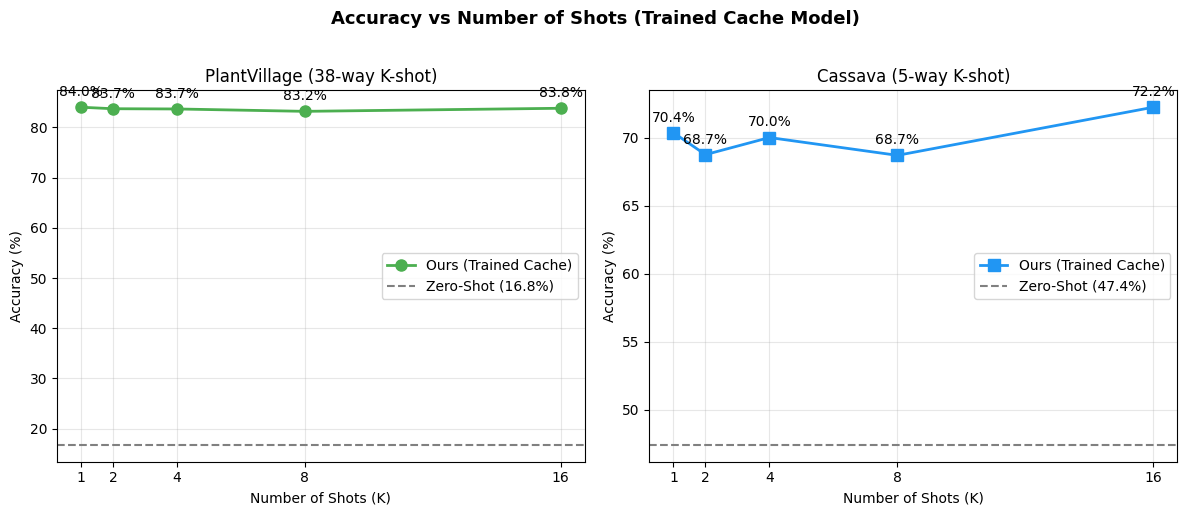

Graph saved to results folder!


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs(f'{BASE_DIR}/results', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
K_values = [1, 2, 4, 8, 16]

# PlantVillage
ax1.plot(K_values, [pv_trained_results[k] for k in K_values],
         marker='o', color='#4CAF50', linewidth=2,
         markersize=8, label='Ours (Trained Cache)')
ax1.axhline(y=pv_zs_acc, color='gray', linestyle='--',
            label=f'Zero-Shot ({pv_zs_acc:.1f}%)')
ax1.set_title('PlantVillage (38-way K-shot)')
ax1.set_xlabel('Number of Shots (K)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(K_values)
ax1.legend()
ax1.grid(True, alpha=0.3)
for k in K_values:
    ax1.annotate(f'{pv_trained_results[k]:.1f}%',
                 (k, pv_trained_results[k]),
                 textcoords="offset points",
                 xytext=(0, 8), ha='center')

# Cassava
ax2.plot(K_values, [cas_trained_results[k] for k in K_values],
         marker='s', color='#2196F3', linewidth=2,
         markersize=8, label='Ours (Trained Cache)')
ax2.axhline(y=cas_zs_acc, color='gray', linestyle='--',
            label=f'Zero-Shot ({cas_zs_acc:.1f}%)')
ax2.set_title('Cassava (5-way K-shot)')
ax2.set_xlabel('Number of Shots (K)')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(K_values)
ax2.legend()
ax2.grid(True, alpha=0.3)
for k in K_values:
    ax2.annotate(f'{cas_trained_results[k]:.1f}%',
                 (k, cas_trained_results[k]),
                 textcoords="offset points",
                 xytext=(0, 8), ha='center')

plt.suptitle('Accuracy vs Number of Shots (Trained Cache Model)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/results/accuracy_vs_shots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved to results folder!")

Training cache model for confusion matrix...
Getting predictions...


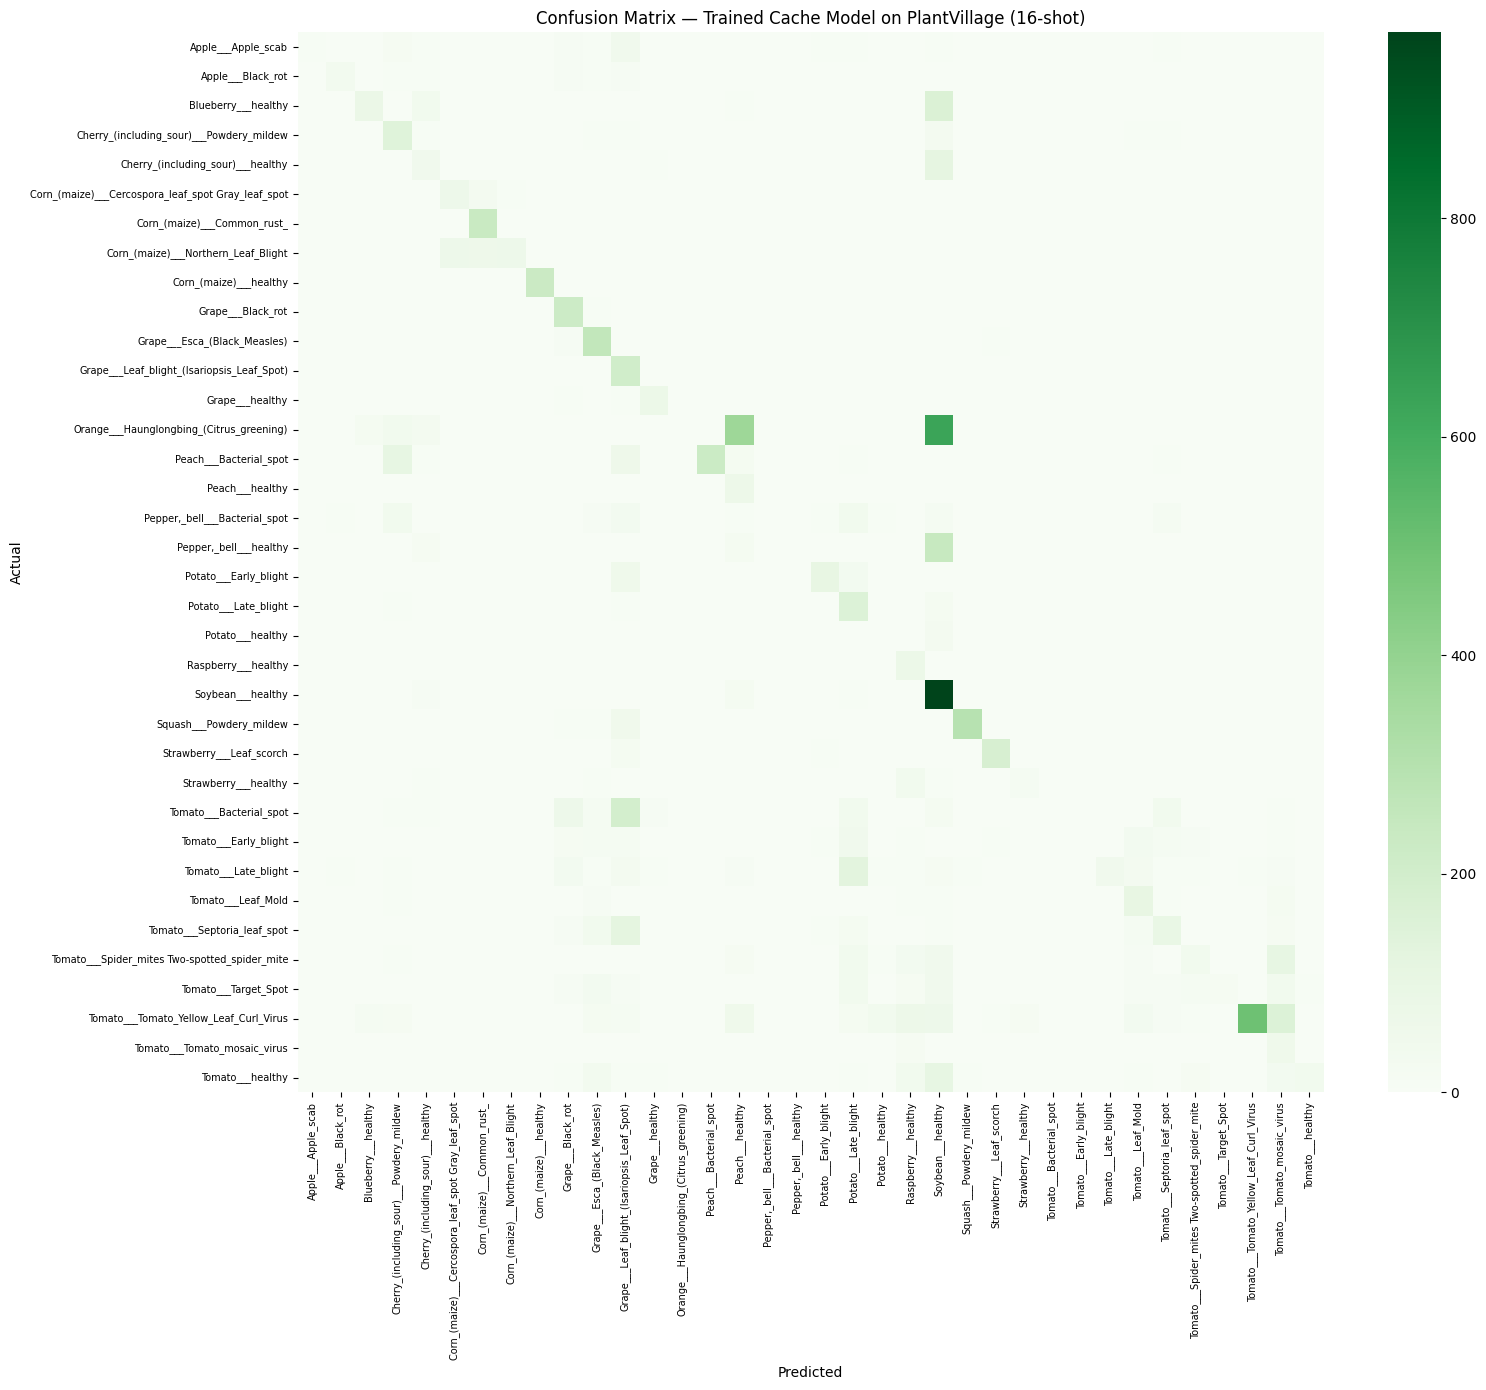

Confusion matrix saved to results folder!


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random

# Build support set with seed for reproducibility
random.seed(42)
pv_support_feats_16, pv_support_lbls_16 = build_support_set(
    pv_train_feats, pv_y_train, pv_classes, K=16
)

# Train cache model for final predictions
print("Training cache model for confusion matrix...")
pv_best_W_final, pv_support_feats_final, pv_support_lbls_final = train_cache_model(
    train_feats  = pv_train_feats,
    train_labels = pv_y_train,
    val_feats    = pv_val_feats,
    val_labels   = pv_y_val,
    text_feats   = pv_text_feats,
    class_names  = pv_classes,
    K        = 16,
    n_epochs = 5,
    lr       = 0.001,
    LAMBDA   = 0.5
)

# Get final predictions using trained cache
print("Getting predictions...")
_, pv_final_preds = trained_cache_predict(
    pv_test_feats,        pv_y_test,
    pv_support_feats_final, pv_support_lbls_final,
    pv_text_feats,        pv_classes,
    pv_best_W_final,      LAMBDA=0.5
)

# Plot confusion matrix
cm = confusion_matrix(pv_y_test, pv_final_preds, labels=pv_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Greens',
            xticklabels=pv_classes,
            yticklabels=pv_classes)
plt.title('Confusion Matrix — Trained Cache Model on PlantVillage (16-shot)',
          fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/results/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved to results folder!")


In [6]:
# Cell: Create project structure and .gitignore
import os

# Create local project folder
os.makedirs('/content/PlantCaFo_GitHub', exist_ok=True)
os.makedirs('/content/PlantCaFo_GitHub/cache', exist_ok=True)
os.makedirs('/content/PlantCaFo_GitHub/results', exist_ok=True)

# Create .gitignore
gitignore_content = """
# Large dataset files — do not upload
datasets/
*.npy
*.pkl
*.pt
*.pth

# Colab checkpoints
.ipynb_checkpoints/
__pycache__/

# System files
.DS_Store
*.pyc

# Large model files
*.bin
*.safetensors
"""

with open('/content/PlantCaFo_GitHub/.gitignore', 'w') as f:
    f.write(gitignore_content)

print("✅ .gitignore created!")

✅ .gitignore created!


In [7]:
import shutil
import os

DRIVE_BASE  = '/content/drive/MyDrive/PlantDisease_Project'
GITHUB_BASE = '/content/PlantCaFo_GitHub'

# ── Copy JSON splits (small, important) ───────────────
for fname in ['pv_splits.json', 'cas_splits.json']:
    src = f'{DRIVE_BASE}/cache/{fname}'
    dst = f'{GITHUB_BASE}/cache/{fname}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ Copied: {fname}")
    else:
        print(f"❌ Not found: {fname}")

# ── Copy results (graphs, confusion matrix) ───────────
results_src = f'{DRIVE_BASE}/results'
results_dst = f'{GITHUB_BASE}/results'

if os.path.exists(results_src):
    for fname in os.listdir(results_src):
        if fname.endswith(('.png', '.jpg', '.pdf')):
            shutil.copy(
                f'{results_src}/{fname}',
                f'{results_dst}/{fname}'
            )
            print(f"✅ Copied result: {fname}")

print("\n✅ All files copied!")

✅ Copied: pv_splits.json
✅ Copied: cas_splits.json
✅ Copied result: accuracy_vs_shots.png
✅ Copied result: confusion_matrix.png

✅ All files copied!
